# Demand Estimation - Part 3: Pricing Analyst

In this section, we use the demand model produced from Part 2 to estimate each brand's costs, markups, and profits.

Average Unit Cost and Markups for Each Brand Over the Years:
              unit_cost     markup
brand                             
chefman       51.709360  39.229052
cosori        76.887975  37.379974
cuisinart    185.142766  38.804327
dash          18.018255  39.460672
gowise usa    45.841720  41.613061
instant_pot   60.972266  43.489087
ninja        101.458295  43.884246
nuwave        99.662834  37.361550
oster        152.664213  36.367071
ultrean       38.939123  39.175483
Average Unit Cost, Price, and Rating for Each Brand
              unit_cost   avg_price  avg_rating
brand                                          
chefman       51.709360   90.938411    4.427966
cosori        76.887975  114.267950    4.656292
cuisinart    185.142766  223.947093    4.438892
dash          18.018255   57.478927    4.476394
gowise usa    45.841720   87.454781    4.576990
instant_pot   60.972266  104.461353    4.559323
ninja        101.458295  145.342541    4.742064
nuwave        99.662834  137.024384

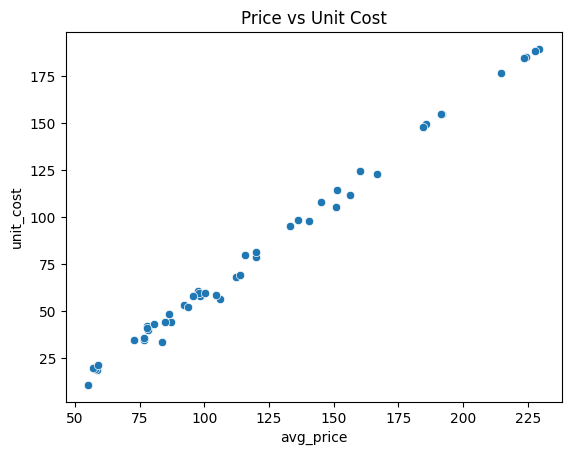

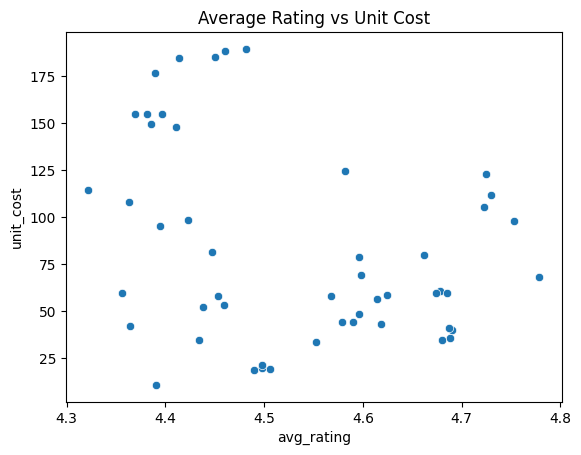

In [ ]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

#Question 1 and Question 2
data = pd.read_csv("sample_data/air_fryers_clean_brand_year.csv") 
priceCoefficient = -0.0282 
data["demand_slope"] = priceCoefficient * data["brand_share"] * (1 - data["brand_share"])
data["unit_cost"] = data["avg_price"] + data["brand_share"] / data["demand_slope"] 
data["markup"] = data["avg_price"] - data["unit_cost"] 
print("Average Unit Cost and Markups for Each Brand Over the Years:")
print(data.groupby("brand")[["unit_cost", "markup"]].mean())

#Question 3
dataCompare = data.groupby("brand")[["unit_cost", "avg_price", "avg_rating"]].mean()
print("Average Unit Cost, Price, and Rating for Each Brand")
print(dataCompare) 
sns.scatterplot(data = data, x = "avg_price", y = "unit_cost")
plt.title("Price vs Unit Cost") 
plt.show() 
sns.scatterplot(data = data, x = "avg_rating", y = "unit_cost")
plt.title("Average Rating vs Unit Cost") 
plt.show()

#### Question 1)
* Highest Average Unit Cost: Cuisinart ($185.14), Oster ($152.66), and Ninja ($101.46)
* Lowest Average Unit Cost: Dash ($18.02), Ultrean ($38.94), and Gowise USA ($45.84) 
* Highest Average Markup: Ninja ($43.88), Instant Pot ($43.49), and Gowise USA ($41.61) 
* Lowest Average Markup: Oster ($36.37), Nuwave ($37.36), and Cosori ($37.38) 
* Based on the data, premium brands tend to have higher average unit costs while Ninja and Instant Pot have the highest average markups.

#### Question 2)
* No inferred unit costs are negative indicating that our model is producing realistic cost estimates. If there had been negative inferred unit costs that would mean a brand is making the product for less than $0, which would indicate that our model produced an unrealistic cost estimate.

#### Question 3)
* The Cuisinart ($185.14), Oster ($152.66), and Ninja ($101.46) brands have the highest average unit costs. Average unit cost and average ratings do not have a clear direct relationship. Low cost brands like Ultrean and Cosori have high ratings while a high cost brand like Ninja also has high ratings. Other high cost brands like Oster have lower ratings than some low cost brands. 
* The Price vs Unit Cost scatterplot indicates a clear direct relationship, revealing that as price increases unit cost increases. 
* The Average Rating vs Unit Cost scatterplot does not indicate a clear relationship, with values being spread out and lacking any clear pattern. 
* Based on the data, more expensive products do not necessarily have higher consumer satisfaction. The Average Rating vs Unit Cost scatterplot illustrates a lack of a relationship between the variables, revealing that higher consumer satisfaction is not directly tied to just higher cost brands, but can be found in lower cost brands as well. The same is true for lower consumer ratings, with these being present in high and low cost brands.